In [1]:
# Classificação Automática de Atividades Culturais e Educacionais
# 01 - Análise exploratória
#
# Integrantes: Beatriz Aparecida de Mello Barbosa (10354067), Bruna Gonçalves Corte David (10425696),
#              Henrique Brainer Costa (10420717), João Pedro Queiroz de Andrade (10425822),
#              Júlia Andrade (10428513)
#
# Conteúdo: junta as três coletas numa tabela única e mede, com contagens simples, por que as
#           categorias publicadas pelos sites não servem como resposta certa.
#
# Alterações:
#   2026-09-25 - Bruna - notebook refeito do zero, reunindo de forma ordenada os experimentos de
#                        análise dos dados que fizemos nos dias anteriores

In [2]:
# ====================================================================================================
#                                     CARREGAMENTO DAS COLETAS
# ====================================================================================================
import pandas as pd                                                   # leitura e manipulação das tabelas
import matplotlib.pyplot as plt                                       # gráficos que vão para o artigo

pd.set_option("display.max_colwidth", 90)                             # deixa a descrição legível no notebook

fabricas_activities = pd.read_csv("../data/raw/fabricas_activities_2026-09-23.csv", sep=";", encoding="utf-8-sig")      # coleta das Fábricas de Cultura
sesc_activities = pd.read_csv("../data/raw/sesc_activities_2026-09-23.csv", sep=";", encoding="utf-8-sig")              # coleta do SESC
sesc_categories = pd.read_csv("../data/raw/sesc_categories_2026-09-25.csv", sep=";", encoding="utf-8-sig")              # segunda coleta do SESC, feita para recuperar as categorias

print("Fábricas:", len(fabricas_activities), "| SESC:", len(sesc_activities), "| Categorias SESC:", len(sesc_categories))

Fábricas: 141 | SESC: 564 | Categorias SESC: 582


In [3]:
fabricas_activities.head(3)                                           # como vem a coleta das Fábricas

,Nome,Categoria,Unidade,Data,Imagem,Descricao
0,DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM LIVROS DE COLORIR – COM EQUIPE BIBLIOTECA,Biblioteca,Capão Redondo,23/09/26,https://www.fabricasdecultura.org.br/wp-content/uploads/2026/07/2026.07.24_DESESTRESSA...,Venha participar da oficina Desestressar Pintando: A Arte de Relaxar com Livros de Col...
1,CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ARTETERAPIA COM FRANCINE SANENE,Biblioteca,Vila Nova Cachoeirinha,23/09/26,https://www.fabricasdecultura.org.br/wp-content/uploads/2026/08/FRANCINE-SANENE-Credit...,Embarque em uma jornada de descobertas com GPS da Ancestralidade! Por meio de história...
2,JARDIM SECRETO – UM DIA PLANTANDO SONHOS COM EQUIPE BIBLIOTECA,Biblioteca,Jardim São Luis,23/09/26,https://www.fabricasdecultura.org.br/wp-content/uploads/2026/07/2026.07.31_JARDIM-SECR...,"Os sonhos são como flores: nascem de pequenos desejos, precisam ser plantados, cuidado..."


In [4]:
sesc_activities.head(3)                                               # como vem a coleta do SESC

,Nome da Atividade,Descrição,Data Proxima seção,Data Primeira seção,Data Ultima seção,Unidade,Categorias,Acesso,Link
0,Faz de Conta,"Vivência teatral lúdica para crianças de 0 a 6 anos, que convida os pequenos a criar p...",2026-09-23 17:30,2026-09-23 16:30,2026-09-23 17:30,Casa Verde,NaN,Gratuito,https://www.sescsp.org.br/programacao/faz-de-conta
1,Vivência de Rope Skipping,A vivência de Rope Skipping propõe a experimentação da corda como prática corporal que...,2026-09-24 12:30,2026-09-22 14:00,2026-09-27 15:00,Casa Verde,NaN,Gratuito,https://www.sescsp.org.br/programacao/vivencia-de-rope-skipping-5
2,Jogo Poullball na Brasilândia,"O Poullball é um jogo coletivo, dinâmico e inclusivo, que estimula o trabalho em equip...",2026-09-24 17:00,2026-09-22 13:00,2026-09-25 17:00,Casa Verde,NaN,Gratuito,https://www.sescsp.org.br/programacao/jogo-poullball-na-brasilandia


Ao abrir a coleta do SESC notamos que a coluna de categoria estava quase toda vazia. Fomos olhar o
JSON que o site usa e descobrimos que as categorias ficam em outro campo, o `tipos_linguagens`, e o
público em `publico_tag`. A segunda coleta pega esses dois campos. A conta abaixo mostra o tamanho
do problema na coleta original.

In [5]:
sesc_with_category = sesc_activities["Categorias"].notna().sum()                  # atividades com categoria no campo que o scraper lia
sesc_without_category = len(sesc_activities) - sesc_with_category                # atividades que ficaram sem categoria nenhuma
percentage_without_category = 100 * sesc_without_category / len(sesc_activities)  # o mesmo número em porcentagem

print("SESC com categoria no campo original:", sesc_with_category)
print("SESC sem categoria no campo original:", sesc_without_category, "(", round(percentage_without_category, 1), "% )")

SESC com categoria no campo original: 49
SESC sem categoria no campo original: 515 ( 91.3 % )


In [6]:
sesc_categories.head(3)                                               # as categorias recuperadas, separadas por barra quando são mais de uma

,id,link,titulo,categorias_json,tipos_linguagens,publico_tag,unidade
0,1254110,https://www.sescsp.org.br/programacao/mini-tenis-de-mesa-metro-barra-funda,Mini Tênis de Mesa - Metrô Barra Funda,NaN,Encontros e Palestras|Esporte e Atividade Física,Diversas idades,Casa Verde
1,1254879,https://www.sescsp.org.br/programacao/bolsa-de-croche,Bolsa de crochê,NaN,Encontros e Palestras|Tecnologias e Artes,Diversas idades,Casa Verde
2,1254297,https://www.sescsp.org.br/programacao/jogo-poullball-na-brasilandia,Jogo Poullball na Brasilândia,NaN,Encontros e Palestras|Esporte e Atividade Física,Diversas idades,Casa Verde


In [7]:
# ====================================================================================================
#                                TABELA ÚNICA COM AS DUAS INSTITUIÇÕES
# ====================================================================================================
fabricas_activities = fabricas_activities.rename(columns={"Nome": "title", "Descricao": "description", "Categoria": "original_categories", "Unidade": "unit"})   # nomes curtos e em inglês
sesc_activities = sesc_activities.rename(columns={"Nome da Atividade": "title", "Descrição": "description", "Unidade": "unit", "Link": "link"})                  # o cabeçalho do SESC vem acentuado

sesc_activities.columns.tolist()                                      # confere os nomes depois do rename

['title',
 'description',
 'Data Proxima seção',
 'Data Primeira seção',
 'Data Ultima seção',
 'unit',
 'Categorias',
 'Acesso',
 'link']

In [8]:
# ----------------------------------------------------------------------------------------------------
#                    CASAR AS CATEGORIAS RECUPERADAS COM AS DESCRIÇÕES, PELO LINK
# ----------------------------------------------------------------------------------------------------
categories_by_link = sesc_categories[["link", "tipos_linguagens", "publico_tag"]]                             # só o que falta na tabela das descrições
sesc_activities = sesc_activities.merge(categories_by_link, on="link", how="left")                            # o link é a chave entre as duas coletas
sesc_activities = sesc_activities.rename(columns={"tipos_linguagens": "original_categories", "publico_tag": "audience"})   # mesmo nome de coluna das Fábricas

sesc_with_recovered_category = sesc_activities["original_categories"].notna().sum()                           # quantas descrições acharam par na outra coleta

print("SESC com categoria depois de casar pelo link:", sesc_with_recovered_category, "de", len(sesc_activities))

SESC com categoria depois de casar pelo link: 483 de 564


As duas coletas foram feitas em dias diferentes, 23/09 e 25/09, e as atividades expiram rápido. As
que não acham par pelo link saíram do site nesse intervalo.

In [9]:
fabricas_activities["source"] = "Fábricas de Cultura"                  # marca de onde veio cada atividade
sesc_activities["source"] = "SESC"                                    # idem
fabricas_activities["audience"] = None                                # as Fábricas não publicam campo de público
fabricas_activities["link"] = None                                    # nem link na coleta das Fábricas

shared_columns = ["source", "unit", "title", "description", "original_categories", "audience", "link"]              # o que interessa para a análise
activities = pd.concat([fabricas_activities[shared_columns], sesc_activities[shared_columns]], ignore_index=True)    # as duas instituições numa tabela só

print("Atividades na tabela única:", len(activities))
activities.head(3)

Atividades na tabela única: 705


,source,unit,title,description,original_categories,audience,link
0,Fábricas de Cultura,Capão Redondo,DESESTRESSAR PINTANDO: A ARTE DE RELAXAR COM LIVROS DE COLORIR – COM EQUIPE BIBLIOTECA,Venha participar da oficina Desestressar Pintando: A Arte de Relaxar com Livros de Col...,Biblioteca,None,None
1,Fábricas de Cultura,Vila Nova Cachoeirinha,CONTAÇÃO DE HISTÓRIA: GPS DA ANCESTRALIDADE + ARTETERAPIA COM FRANCINE SANENE,Embarque em uma jornada de descobertas com GPS da Ancestralidade! Por meio de história...,Biblioteca,None,None
2,Fábricas de Cultura,Jardim São Luis,JARDIM SECRETO – UM DIA PLANTANDO SONHOS COM EQUIPE BIBLIOTECA,"Os sonhos são como flores: nascem de pequenos desejos, precisam ser plantados, cuidado...",Biblioteca,None,None


In [10]:
activities["text"] = activities["title"] + ". " + activities["description"]     # texto que vai para o modelo: título resume, descrição detalha
activities = activities.dropna(subset=["text"])                                # linha sem texto não serve
activities = activities.drop_duplicates(subset=["title", "description"])       # a mesma atividade aparece repetida quando acontece em duas unidades

print("Atividades com texto e sem repetição:", len(activities))

Atividades com texto e sem repetição: 693


In [11]:
activities.to_csv("../data/processed/activities.csv", sep=";", index=False, encoding="utf-8-sig")   # tabela que os próximos notebooks usam

print("Tabela salva em data/processed/activities.csv")

Tabela salva em data/processed/activities.csv


In [12]:
# ====================================================================================================
#                              CARACTERIZAÇÃO: QUEM SÃO ESSAS ATIVIDADES
# ====================================================================================================
activities_per_source = activities["source"].value_counts()           # quantas atividades vieram de cada instituição

activities_per_source

source
SESC                   564
Fábricas de Cultura    129
Name: count, dtype: int64

In [13]:
activities_per_unit = activities["unit"].value_counts()                # quantas atividades em cada unidade

print("Unidades diferentes:", activities["unit"].nunique())
activities_per_unit

Unidades diferentes: 14


unit
Consolação                       146
Pompeia                          103
Centro de Pesquisa e Formação     98
Santana                           58
Avenida Paulista                  55
Capão Redondo                     43
14 Bis                            43
Casa Verde                        34
Jardim São Luis                   31
CineSesc                          26
Jaçanã                            16
Vila Nova Cachoeirinha            14
Brasilândia                       13
Núcleo Taipas                     12
Name: count, dtype: int64

In [14]:
activities["word_count"] = activities["text"].str.split().str.len()         # tamanho do texto de cada atividade, em palavras

text_length_per_source = activities.groupby("source")["word_count"].describe()[["count", "mean", "50%", "min", "max"]]   # resumo do tamanho por instituição
text_length_per_source

,count,mean,50%,min,max
source,,,,,
Fábricas de Cultura,129.0,76.255814,71.0,29.0,226.0
SESC,564.0,134.907801,118.5,4.0,643.0


O SESC escreve descrições bem mais longas que as Fábricas. Isso importa porque uma representação
baseada em contagem de palavras tende a achar que textos longos são parecidos entre si só por terem
mais palavras em comum.

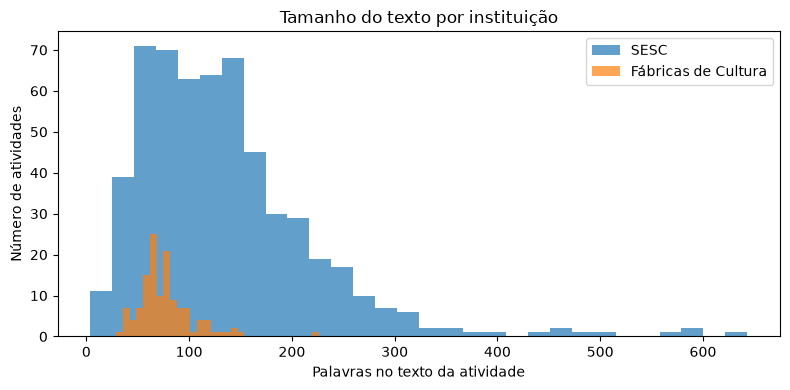

In [15]:
# ----------------------------------------------------------------------------------------------------
#                           GRÁFICO: TAMANHO DO TEXTO EM CADA INSTITUIÇÃO
# ----------------------------------------------------------------------------------------------------
plt.figure(figsize=(8, 4))                                                                                                              # tamanho do gráfico em polegadas
plt.hist(activities[activities["source"] == "SESC"]["word_count"], bins=30, alpha=0.7, label="SESC")                                    # distribuição do SESC
plt.hist(activities[activities["source"] == "Fábricas de Cultura"]["word_count"], bins=30, alpha=0.7, label="Fábricas de Cultura")       # distribuição das Fábricas
plt.xlabel("Palavras no texto da atividade")                                                                                            # rótulo do eixo horizontal
plt.ylabel("Número de atividades")                                                                                                      # rótulo do eixo vertical
plt.title("Tamanho do texto por instituição")                                                                                           # título que vai junto no artigo
plt.legend()                                                                                                                            # identifica as duas instituições
plt.tight_layout()                                                                                                                      # evita cortar os rótulos
plt.savefig("../paper/latex/figures/text_length.png", dpi=150)                                                                          # figura usada no artigo
plt.show()

In [16]:
# ====================================================================================================
#                           O PROBLEMA: AS CATEGORIAS PUBLICADAS PELOS SITES
# ====================================================================================================
categories_as_list = activities["original_categories"].dropna().str.split("|")             # o SESC traz várias categorias separadas por barra
single_categories = categories_as_list.explode().str.strip()                               # uma linha por categoria, para poder contar

activities_per_category = single_categories.value_counts()                                 # quantas atividades em cada categoria

print("Categorias diferentes nas duas instituições:", len(activities_per_category))
activities_per_category

Categorias diferentes nas duas instituições: 36


original_categories
Cursos e Oficinas                    175
Esporte e Atividade Física           148
Encontros e Palestras                 98
Tecnologias e Artes                   80
Música                                77
Shows, Espetáculos e Performances     49
Ações para a Cidadania                44
Biblioteca                            40
Eventos Físico-Esportivos             38
Cinema                                35
Práticas Corporais                    30
Programa Sesc de Esportes             28
Literatura                            27
Artes Visuais                         18
Dança                                 15
Teatro                                15
Circo                                 15
Oficina                               14
Gestão Cultural                       13
Shows / Apresentações Musicais        11
Práticas Aquáticas                    10
Meio Ambiente                          7
Artes Cênicas                          6
Alimentação                          

In [17]:
# ----------------------------------------------------------------------------------------------------
#                        CONCENTRAÇÃO: POUCAS CATEGORIAS LEVAM QUASE TUDO
# ----------------------------------------------------------------------------------------------------
total_category_assignments = activities_per_category.sum()                                              # total de vezes que alguma categoria foi atribuída
share_of_three_largest = 100 * activities_per_category.head(3).sum() / total_category_assignments        # o quanto as três maiores concentram
rare_categories = activities_per_category[activities_per_category <= 5]                                  # categorias com no máximo 5 atividades

print("Atribuições de categoria no total:", total_category_assignments)
print("Peso das 3 maiores categorias:", round(share_of_three_largest, 1), "%")
print("Categorias com 5 atividades ou menos:", len(rare_categories), "de", len(activities_per_category))
rare_categories

Atribuições de categoria no total: 1034
Peso das 3 maiores categorias: 40.7 %
Categorias com 5 atividades ou menos: 13 de 36


original_categories
Alimentação                 5
Turismo Social              5
Ginástica Multifuncional    5
Jogos e Brincadeiras        4
Bate-papo                   4
Exposições                  4
Contação de História        3
Mostras e Exposições        3
Slams/ Saraus               3
Empreendedorismo            2
Meio ambiente               1
Moda                        1
Saúde                       1
Name: count, dtype: int64

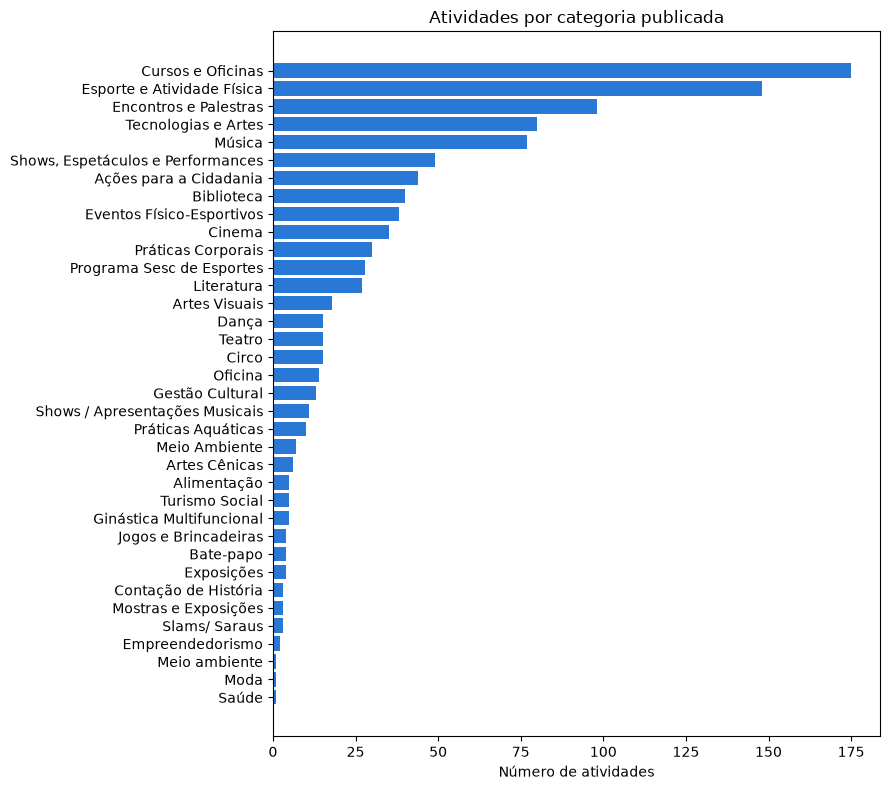

In [18]:
# ----------------------------------------------------------------------------------------------------
#                            GRÁFICO: ATIVIDADES POR CATEGORIA PUBLICADA
# ----------------------------------------------------------------------------------------------------
plt.figure(figsize=(9, 8))                                                                                  # tamanho do gráfico em polegadas
plt.barh(activities_per_category.index, activities_per_category.values, color="#2a78d6")                     # barras deitadas, uma por categoria
plt.gca().invert_yaxis()                                                                                    # categoria maior aparece em cima
plt.xlabel("Número de atividades")                                                                          # rótulo do eixo horizontal
plt.title("Atividades por categoria publicada")                                                             # título que vai junto no artigo
plt.tight_layout()                                                                                          # evita cortar os nomes das categorias
plt.savefig("../paper/latex/figures/activities_per_category.png", dpi=150)                                  # figura usada no artigo
plt.show()

In [19]:
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
#                       SOBREPOSIÇÃO: QUANTAS CATEGORIAS CADA ATIVIDADE RECEBE
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
categories_per_activity = categories_as_list.str.len()                                      # quantas categorias cada atividade recebeu
label_count_distribution = categories_per_activity.value_counts().sort_index()               # quantas atividades têm 1, 2, 3 categorias

print("Média de categorias por atividade:", round(categories_per_activity.mean(), 2))
label_count_distribution

Média de categorias por atividade: 1.69


original_categories
1    202
2    398
3     12
Name: count, dtype: int64

In [20]:
# ----------------------------------------------------------------------------------------------------
#                   PARES DE CATEGORIAS QUE MAIS APARECEM JUNTAS NA MESMA ATIVIDADE
# ----------------------------------------------------------------------------------------------------
from itertools import combinations                                                          # gera os pares de categorias de cada atividade

category_pairs = []                                                                         # guarda um par por vez que duas categorias se encontram
for category_list in categories_as_list:
    clean_categories = sorted(category.strip() for category in category_list)                # ordena para o par (A, B) não virar (B, A)
    category_pairs.extend(combinations(clean_categories, 2))                                 # todos os pares possíveis dentro da atividade

most_frequent_pairs = pd.Series(category_pairs).value_counts().head(10)                       # os 10 pares que mais se repetem
most_frequent_pairs

(Cursos e Oficinas, Tecnologias e Artes)                   72
(Esporte e Atividade Física, Eventos Físico-Esportivos)    38
(Cursos e Oficinas, Música)                                34
(Esporte e Atividade Física, Práticas Corporais)           30
(Esporte e Atividade Física, Programa Sesc de Esportes)    28
(Ações para a Cidadania, Cursos e Oficinas)                25
(Música, Shows, Espetáculos e Performances)                24
(Ações para a Cidadania, Encontros e Palestras)            19
(Encontros e Palestras, Esporte e Atividade Física)        17
(Encontros e Palestras, Literatura)                        16
Name: count, dtype: int64

In [21]:
# ----------------------------------------------------------------------------------------------------
#                    A CATEGORIA MAIS GENÉRICA QUASE NUNCA APARECE SOZINHA
# ----------------------------------------------------------------------------------------------------
broadest_category = "Encontros e Palestras"                                                              # aparece em atividades de qualquer assunto
rows_with_broadest_category = single_categories[single_categories == broadest_category].index             # linhas das atividades que a receberam
their_full_category_lists = categories_as_list.loc[rows_with_broadest_category]                           # as listas completas dessas atividades
accompanied_by_another = their_full_category_lists[their_full_category_lists.str.len() > 1]               # as que também receberam outra categoria

print("Atividades em", broadest_category, ":", len(their_full_category_lists))
print("Delas, quantas vêm acompanhadas de outra categoria:", len(accompanied_by_another))

Atividades em Encontros e Palestras : 98
Delas, quantas vêm acompanhadas de outra categoria: 87


Uma categoria que quase nunca aparece sozinha não está dizendo do que a atividade trata. Ela diz que
a atividade é um encontro com pessoas, que é outro tipo de pergunta. Por isso uma partida de futebol
e uma oficina de crochê caem no mesmo lugar.

In [22]:
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
#                   AS CATEGORIAS RESPONDEM PERGUNTAS DIFERENTES ENTRE SI
# =-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-=-
question_answered_by_category = {"Cursos e Oficinas": "que formato tem", "Encontros e Palestras": "que formato tem", "Shows, Espetáculos e Performances": "que formato tem", "Mostras e Exposições": "que formato tem", "Oficina": "que formato tem", "Bate-papo": "que formato tem", "Música": "que arte é", "Dança": "que arte é", "Artes Cênicas": "que arte é", "Artes Visuais": "que arte é", "Literatura": "que arte é", "Cinema": "que arte é", "Teatro": "que arte é", "Circo": "que arte é", "Biblioteca": "quem organizou", "Esporte e Atividade Física": "sobre o que é", "Tecnologias e Artes": "sobre o que é", "Meio ambiente": "sobre o que é", "Empreendedorismo": "sobre o que é", "Moda": "sobre o que é"}   # leitura manual, categoria por categoria

question_of_each_category = pd.Series(question_answered_by_category)                        # categoria -> pergunta que ela responde
categories_per_question = question_of_each_category.value_counts()                          # quantas categorias respondem cada pergunta

print("Categorias que conseguimos classificar assim:", len(question_of_each_category), "de", len(activities_per_category))
categories_per_question

Categorias que conseguimos classificar assim: 20 de 36


que arte é         8
que formato tem    6
sobre o que é      5
quem organizou     1
Name: count, dtype: int64

Lendo os nomes um por um, percebemos que eles não respondem a mesma pergunta. "Música" responde que
arte é aquilo, "Cursos e Oficinas" responde que formato a atividade tem e "Biblioteca" responde qual
setor da casa organizou. Como ficam todos na mesma lista de filtros, quem usa o site não tem como
saber qual pergunta está fazendo quando clica.

In [23]:
# ----------------------------------------------------------------------------------------------------
#                    A CATEGORIA NÃO ACOMPANHA O TEXTO: O CASO DA PALAVRA "OFICINA"
# ----------------------------------------------------------------------------------------------------
text_mentions_workshop = activities["text"].str.lower().str.contains("oficina")                                      # atividades que se descrevem como oficina
category_mentions_workshop = activities["original_categories"].fillna("").str.lower().str.contains("oficina")         # atividades classificadas em alguma categoria de oficina

print("Texto menciona oficina:", text_mentions_workshop.sum())
print("Categoria menciona oficina:", category_mentions_workshop.sum())
print("As duas coisas ao mesmo tempo:", (text_mentions_workshop & category_mentions_workshop).sum())

Texto menciona oficina: 83
Categoria menciona oficina: 189
As duas coisas ao mesmo tempo: 46


In [24]:
# ----------------------------------------------------------------------------------------------------
#                    EXEMPLO CONCRETO: O QUE CABE DENTRO DE "TECNOLOGIAS E ARTES"
# ----------------------------------------------------------------------------------------------------
vague_category_examples = activities[activities["original_categories"].fillna("").str.contains("Tecnologias e Artes")]   # a categoria que citamos na Parte 1 como exemplo ruim

print("Atividades em Tecnologias e Artes:", len(vague_category_examples))
vague_category_examples[["title", "original_categories"]].head(10)

Atividades em Tecnologias e Artes: 80


,title,original_categories
147,Bolsa de crochê,Encontros e Palestras|Tecnologias e Artes
156,Digital de Bolso: Verdade em disputa na era da desinformação,Cursos e Oficinas|Ações para a Cidadania|Tecnologias e Artes
158,PapelETA: Kirigami,Encontros e Palestras|Tecnologias e Artes
159,Camisa de Crochê,Cursos e Oficinas|Tecnologias e Artes
160,Entre Nós: Impressão botânica em tecido,Cursos e Oficinas|Tecnologias e Artes
168,AteliArte: Pintura à óleo,Cursos e Oficinas|Tecnologias e Artes
180,Bordando Memórias Afetivas: Ressignificar e Contar Histórias,Cursos e Oficinas|Tecnologias e Artes
185,Livros Esquisitos,Cursos e Oficinas|Tecnologias e Artes
201,Criando Jóias Têxteis,Cursos e Oficinas|Tecnologias e Artes
202,Plantão de dúvidas: Bê-a-bá digital,Cursos e Oficinas|Tecnologias e Artes


In [25]:
# ----------------------------------------------------------------------------------------------------
#                     CONCENTRAÇÃO DENTRO DAS FÁBRICAS: QUASE TUDO É BIBLIOTECA
# ----------------------------------------------------------------------------------------------------
fabricas_per_category = activities[activities["source"] == "Fábricas de Cultura"]["original_categories"].value_counts()   # cada atividade das Fábricas tem uma categoria só
share_of_largest_category = 100 * fabricas_per_category.iloc[0] / fabricas_per_category.sum()                             # o quanto a maior concentra

print("Maior categoria das Fábricas:", fabricas_per_category.index[0], "com", round(share_of_largest_category, 1), "% das atividades")
fabricas_per_category

Maior categoria das Fábricas: Biblioteca com 31.0 % das atividades


original_categories
Biblioteca                        40
Oficina                           14
Música                            11
Shows / Apresentações Musicais    11
Dança                              8
Artes Cênicas                      6
Artes Visuais                      5
Literatura                         4
Jogos e Brincadeiras               4
Bate-papo                          4
Cinema                             3
Teatro                             3
Contação de História               3
Circo                              3
Mostras e Exposições               3
Slams/ Saraus                      3
Empreendedorismo                   2
Meio ambiente                      1
Moda                               1
Name: count, dtype: int64

In [26]:
# ----------------------------------------------------------------------------------------------------
#                AS DUAS INSTITUIÇÕES NOMEIAM A MESMA COISA DE FORMAS DIFERENTES
# ----------------------------------------------------------------------------------------------------
categories_with_source = activities[["source", "original_categories"]].dropna()                                            # só as atividades que têm categoria
categories_with_source = categories_with_source.assign(category=categories_with_source["original_categories"].str.split("|")).explode("category")   # uma linha por categoria
categories_with_source["category"] = categories_with_source["category"].str.strip()                                        # tira espaço sobrando do nome

categories_of_each_source = categories_with_source.groupby("source")["category"].apply(set)                                 # o conjunto de categorias de cada instituição
categories_in_common = categories_of_each_source["SESC"] & categories_of_each_source["Fábricas de Cultura"]                  # as que as duas escrevem igual

print("Categorias do SESC:", len(categories_of_each_source["SESC"]))
print("Categorias das Fábricas:", len(categories_of_each_source["Fábricas de Cultura"]))
print("Categorias escritas igual nas duas:", len(categories_in_common), sorted(categories_in_common))

Categorias do SESC: 24
Categorias das Fábricas: 19
Categorias escritas igual nas duas: 7 ['Artes Visuais', 'Cinema', 'Circo', 'Dança', 'Literatura', 'Música', 'Teatro']


Quase nada coincide. As duas instituições recortam o mesmo tipo de atividade com listas diferentes,
e em alguns casos com nomes parecidos mas não iguais, como "Oficina" e "Cursos e Oficinas", ou
"Exposições" e "Mostras e Exposições". Juntar as duas bases usando as categorias que elas já têm não
daria certo, o que reforça a ideia de criar categorias novas a partir dos textos.

In [27]:
activities_without_category = activities["original_categories"].isna().sum()                 # atividades que chegaram sem categoria nenhuma
percentage_without_category = 100 * activities_without_category / len(activities)             # o mesmo número em porcentagem

print("Atividades sem categoria nenhuma:", activities_without_category, "(", round(percentage_without_category, 1), "% )")
print("Atividades com texto aproveitável:", len(activities))

Atividades sem categoria nenhuma: 81 ( 11.7 % )
Atividades com texto aproveitável: 693
